<a href="https://colab.research.google.com/github/janacb23/03MIAR-Algoritmos-de-Optimizacion/blob/main/Jana_Calcerrada_Trabajo_Pr%C3%A1ctico_Algoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Jana Calcerrada Barrigüete  <br>
Url: https://github.com/janacb23/03MIAR-Algoritmos-de-Optimizacion.git<br>
Google Colab: https://colab.research.google.com/drive/10DVKqF4ELoZfsLxRDSuTXJNDVrbI2Rx6?usp=sharing <br>
Problema:
>2. Organizar los horarios de partidos de una jornada de La Liga<br>


Descripción del problema:

• Desde la La Liga de fútbol profesional se pretende organizar los horarios de los
partidos de liga de cada jornada. Se conocen algunos datos que nos deben llevar a
diseñar un algoritmo que realice la asignación de los partidos a los horarios de forma
que maximice la audiencia.

• Los horarios disponibles se conocen a priori y son los siguientes:

Viernes 20

Sábado 12,16,18,20

Domingo 12,16,18,20

Lunes 20

• En primer lugar se clasifican los equipos en tres categorías según el numero de
seguidores( que tiene relación directa con la audiencia). Hay 3 equipos en la
categoría A, 11 equipos de categoría B y 6 equipos de categoría C.

• Se conoce estadísticamente la audiencia que genera cada partido según los equipos
que se enfrentan y en horario de sábado a las 20h (el mejor en todos los casos)

                 Categoría A   Categoría B   Categoría C
    Categoría A  2 Millones    1,3 Millones  1 Millones
    Categoría B                0.9 Millones  0.75 Millones
    Categoría C                              0.47 Millones



• Si el horario del partido no se realiza a las 20 horas del sábado se sabe que se reduce
según los coeficientes de la siguiente tabla

• Debemos asignar obligatoriamente siempre un partido el viernes y un partido el lunes

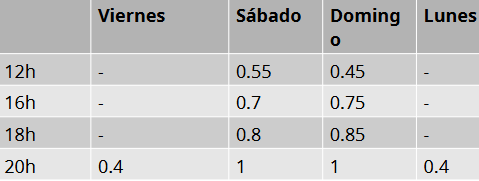

• Es posible la coincidencia de horarios pero en este
caso la audiencia de cada partido se verá afectada y
se estima que se reduce en porcentaje según la
siguiente tabla dependiendo del número de
coincidencias:
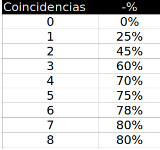


Los cálculos asociados a una jornada de ejemplo se realizan según se muestra en la
siguiente tabla:
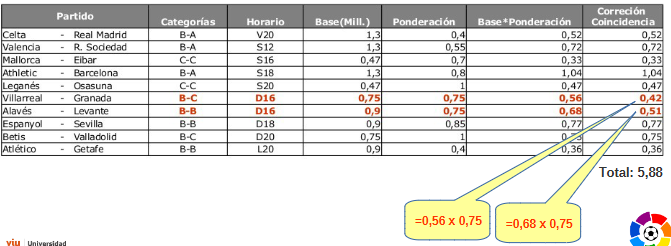


#Modelo
- ¿Como represento el espacio de soluciones?
- ¿Cual es la función objetivo?
- ¿Como implemento las restricciones?

El espacio de soluciones se puede representar como un vector de 10 posiciones (una por cada partido de la jornada). Cada posición del vector contiene un índice que corresponde a uno de los 10 horarios disponibles (V20, S12, S16, S18, S20, D12, D16, D18, D20, L20).

$S = [h_0, h_1, ..., h_{9}]$ donde $h_i \in \{0, 1, ..., 9\}$.

La función objetivo es maximizar la audiencia total ($A_{total}$) de la jornada. Se calcula sumando la audiencia de cada partido $i$ según su base, la ponderación horaria y las penalizaciones por coincidencia :

$$f(x) = \sum_{i=1}^{10} (\text{Base}_i \times \text{Ponderación}_{h} \times (1 - \text{Reducción}_{c}))$$

Donde:


* Base: Según categorías de los equipos (A, B o C) .


* Ponderación: Coeficiente del horario elegido.


* Reducción: Porcentaje de pérdida si hay otros partidos en el mismo horario.

Las restricciones se pueden implementar mediante funciones de validación o penalizaciones en la función fitness:

1.   Al menos un partido tiene que estar asignado el viernes a las 20h y otro el lunes a las 20h.
2.  Cada uno de los 10 partidos de la jornada tiene que tener asignado exactamente un horario.

In [1]:
#Respuesta
import random
import math

# 1. Datos Base
categorias_audiencia = {
    ('A', 'A'): 2.0, ('A', 'B'): 1.3, ('A', 'C'): 1.0,
    ('B', 'B'): 0.9, ('B', 'C'): 0.75, ('C', 'C'): 0.47
}

ponderacion_horaria = {
    'V20': 0.4, 'L20': 0.4,
    'S12': 0.55, 'S16': 0.7, 'S18': 0.8, 'S20': 1.0,
    'D12': 0.45, 'D16': 0.75, 'D18': 0.85, 'D20': 1.0
}

reduccion_coincidencia = {
    0: 0.0, 1: 0.25, 2: 0.45, 3: 0.60, 4: 0.70,
    5: 0.75, 6: 0.78, 7: 0.80, 8: 0.80
}

# Ejemplo de jornada (10 partidos)
jornada = [
    ('B', 'A'), ('B', 'A'), ('C', 'C'), ('B', 'A'), ('C', 'C'),
    ('B', 'C'), ('B', 'B'), ('B', 'B'), ('B', 'C'), ('B', 'B')
]

horarios = list(ponderacion_horaria.keys())

def calcular_audiencia(asignacion):
    """
    Calcula la audiencia total de una asignación específica.
    asignacion: lista de índices de horarios para cada partido.
    """
    # Contar coincidencias por horario
    conteos = {}
    for h_idx in asignacion:
        h = horarios[h_idx]
        conteos[h] = conteos.get(h, 0) + 1

    # Restricción obligatoria: Viernes y Lunes ocupados
    if conteos.get('V20', 0) == 0 or conteos.get('L20', 0) == 0:
        return 0 # Penalización total por incumplir restricción

    audiencia_total = 0
    for i, h_idx in enumerate(asignacion):
        partido = jornada[i]
        h = horarios[h_idx]

        # Obtener base según categorías
        cat = tuple(sorted(partido))
        base = categorias_audiencia.get(cat, 0.47)

        # Aplicar ponderación y reducción por coincidencia
        n_coincidencias = conteos[h] - 1
        p_red = reduccion_coincidencia.get(n_coincidencias, 0.80)

        audiencia_partido = base * ponderacion_horaria[h] * (1 - p_red)
        audiencia_total += audiencia_partido

    return audiencia_total

# 2. Algoritmo de Búsqueda Aleatoria / Hill Climbing Simple
def optimizar_horarios(iteraciones=50000):
    mejor_solucion = [random.randint(0, 9) for _ in range(10)]
    mejor_audiencia = calcular_audiencia(mejor_solucion)

    for _ in range(iteraciones):
        # Crear nueva solución vecina
        nueva_solucion = list(mejor_solucion)
        partido_a_cambiar = random.randint(0, 9)
        nueva_solucion[partido_a_cambiar] = random.randint(0, 9)

        nueva_audiencia = calcular_audiencia(nueva_solucion)

        if nueva_audiencia > mejor_audiencia:
            mejor_audiencia = nueva_audiencia
            mejor_solucion = nueva_solucion

    return mejor_solucion, mejor_audiencia

# Ejecución
sol, aud = optimizar_horarios()
print(f"Mejor audiencia encontrada: {aud:.2f} Millones")
for i, h_idx in enumerate(sol):
    print(f"Partido {i+1} ({jornada[i][0]}-{jornada[i][1]}): {horarios[h_idx]}")

Mejor audiencia encontrada: 6.69 Millones
Partido 1 (B-A): S18
Partido 2 (B-A): S20
Partido 3 (C-C): S12
Partido 4 (B-A): D18
Partido 5 (C-C): V20
Partido 6 (B-C): S16
Partido 7 (B-B): D20
Partido 8 (B-B): L20
Partido 9 (B-C): D12
Partido 10 (B-B): D16


#Análisis
- ¿Que complejidad tiene el problema?. Orden de complejidad y Contabilizar el espacio de soluciones

Contabilizar el espacio de soluciones: El problema consiste en asignar 10 partidos a 10 posibles franjas horarias. Como los horarios pueden repetirse (coincidencias), el espacio de búsqueda total es de $10^{10}$ = 10.000.000.000 de soluciones posibles

Orden de complejidad: Es un problema de optimización combinatoria que pertenece a la clase NP-Duro. El tiempo necesario para encontrar la solución óptima mediante fuerza bruta crece exponencialmente con el número de partidos y horarios, haciéndola inviable en la práctica.

#Diseño
- ¿Que técnica utilizo? ¿Por qué?

Se ha implementado una metaheurística de Búsqueda Local (algoritmo de Hill Climbing con búsqueda aleatoria), ya que:

1. En un espacio de $10^{10}$ soluciones, esta técnica permite explorar de forma inteligente y encontrar una solución de alta calidad (cercana al óptimo) en un tiempo de ejecución muy reducido (segundos).

2. El algoritmo permite integrar fácilmente las restricciones obligatorias (partidos en viernes y lunes) mediante penalizaciones en la función objetivo (devolviendo audiencia 0 si no se cumplen).

3. Como las penalizaciones por coincidencia afectan a varios partidos a la vez, la función de audiencia no es lineal. Este tipo de problemas son demasiado complejos para resolverse con programación lineal básica, por eso las metaheurísticas resultan una mejor opción.